<a href="https://colab.research.google.com/github/Justus3031/BUSINESS-PROJECT/blob/main/HBV_Analysis_2_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data

In [4]:
import pandas as pd

# To load all sheets, set sheet_name=None
all_sheets = pd.read_excel('/content/drive/MyDrive/HBV (1).xlsx', sheet_name=None)

print('Sheets loaded:', all_sheets.keys())

# The 'data' variable currently holds the first sheet, or you can pick any sheet by name:
# For example, to access the first sheet that was loaded (which was originally in 'data'):
data = all_sheets[list(all_sheets.keys())[0]]

display(data.head())

Sheets loaded: dict_keys(['Akwanga', 'Awe', 'Doma', 'Karu', 'keana', 'Keffi', 'Kokona', 'Lafia', 'Nasarawa Eggon', 'Nasarawa', 'Obi', 'Toto', 'Wamba', 'Year_Month'])


,Year_Month,ANC Hep. B test done,ANC Hep. B test positive
0,2025-1,823,32
1,2025-2,566,22
2,2025-3,696,8
3,2025-4,585,22
4,2025-5,624,27


### Yearly Prevalence Table

In [17]:
yearly_display_df = yearly_summary.rename(columns={
    'Year_Only': 'Year',
    'Total_Sampled': 'Total Screened (n)',
    'Total_Positive': 'Total HBV-Positive (n)',
    'Yearly_Prevalence': 'Prevalence (%)'
})

# Reorder columns as requested
yearly_display_df = yearly_display_df[['Year', 'Total Screened (n)', 'Total HBV-Positive (n)', 'Prevalence (%)']]

# Calculate totals for the yearly table
yearly_total_screened = yearly_display_df['Total Screened (n)'].sum()
yearly_total_positive = yearly_display_df['Total HBV-Positive (n)'].sum()
yearly_overall_prevalence = (yearly_total_positive / yearly_total_screened) * 100

# Create a 'Total' row for the yearly table
yearly_total_row = pd.DataFrame([{
    'Year': 'Total',
    'Total Screened (n)': yearly_total_screened,
    'Total HBV-Positive (n)': yearly_total_positive,
    'Prevalence (%)': yearly_overall_prevalence
}])

# Append the total row to the yearly display DataFrame
yearly_display_df = pd.concat([yearly_display_df, yearly_total_row], ignore_index=True)

display(yearly_display_df)

,Year,Total Screened (n),Total HBV-Positive (n),Prevalence (%)
0,2020,14527,1990,13.698630
1,2021,46289,4515,9.753937
2,2022,50662,4393,8.671193
3,2023,74084,6762,9.127477
4,2024,96493,7265,7.529044
5,2025,129846,8479,6.530043
6,Total,411901,33404,8.109716


### Yearly Prevalence Trend Visualization

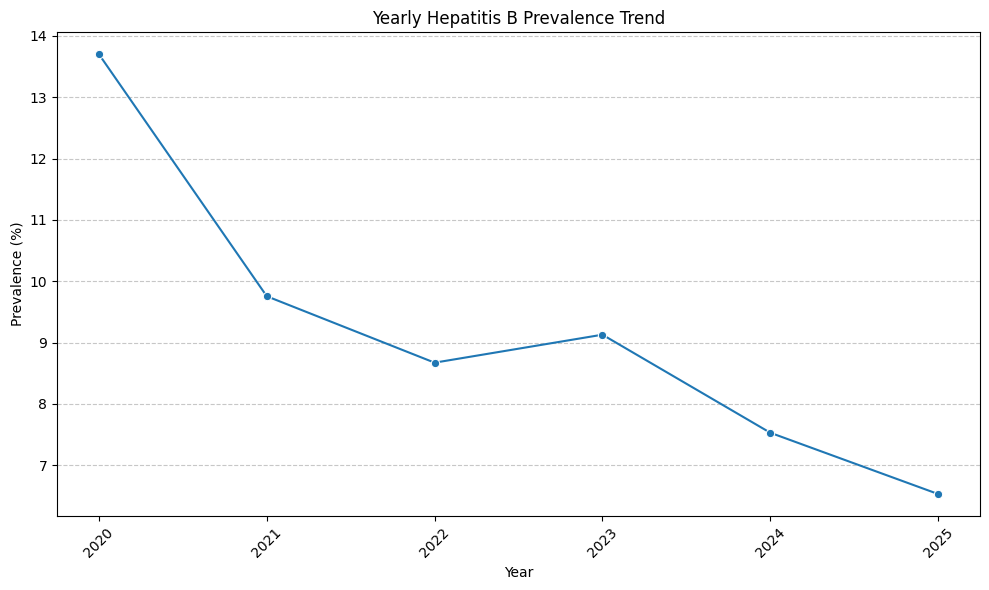

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out the 'Total' row for plotting
yearly_plot_df = yearly_display_df[yearly_display_df['Year'] != 'Total'].copy()
yearly_plot_df['Year'] = yearly_plot_df['Year'].astype(int) # Ensure year is numeric for proper sorting

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Prevalence (%)', data=yearly_plot_df, marker='o') # Changed to lineplot with markers
plt.title('Yearly Hepatitis B Prevalence Trend')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

### Monthly Prevalence Table (January - December)

In [16]:
import calendar
import pandas as pd

# Extract month number and name
df_year_month['Month_Num'] = df_year_month['Date'].dt.month
df_year_month['Month_Name'] = df_year_month['Date'].dt.strftime('%B')

# Group by month and calculate totals
monthly_summary = df_year_month.groupby(['Month_Num', 'Month_Name']).agg(
    Total_Positive=('Positive', 'sum'),
    Total_Sampled=('Sampled', 'sum')
).reset_index()

# Sort monthly_summary by Month_Num to ensure correct order (Jan-Dec) before further processing
monthly_summary.sort_values(by='Month_Num', inplace=True)

# Calculate monthly prevalence
monthly_summary['Prevalence (%)'] = (monthly_summary['Total_Positive'] / monthly_summary['Total_Sampled']) * 100

# Select and rename columns for display
monthly_display_df = monthly_summary[['Month_Name', 'Total_Sampled', 'Total_Positive', 'Prevalence (%)']].rename(columns={
    'Month_Name': 'Month',
    'Total_Sampled': 'Total Screened (n)',
    'Total_Positive': 'Total HBV-Positive (n)'
})

# Calculate totals for the monthly table
monthly_total_screened = monthly_display_df['Total Screened (n)'].sum()
monthly_total_positive = monthly_display_df['Total HBV-Positive (n)'].sum()
monthly_overall_prevalence = (monthly_total_positive / monthly_total_screened) * 100

# Create a 'Total' row for the monthly table
monthly_total_row = pd.DataFrame([{
    'Month': 'Total',
    'Total Screened (n)': monthly_total_screened,
    'Total HBV-Positive (n)': monthly_total_positive,
    'Prevalence (%)': monthly_overall_prevalence
}])

# Append the total row to the monthly display DataFrame
monthly_display_df = pd.concat([monthly_display_df, monthly_total_row], ignore_index=True)

display(monthly_display_df)

,Month,Total Screened (n),Total HBV-Positive (n),Prevalence (%)
0,January,31527,1808,5.734767
1,February,27136,2428,8.947524
2,March,28533,2417,8.470893
3,April,31356,1997,6.368797
4,May,32661,2575,7.884021
5,June,32551,3162,9.713987
6,July,33336,3995,11.984041
7,August,37209,2468,6.632804
8,September,38456,2901,7.543686
9,October,39919,3682,9.223678


### Monthly Prevalence Trend Visualization

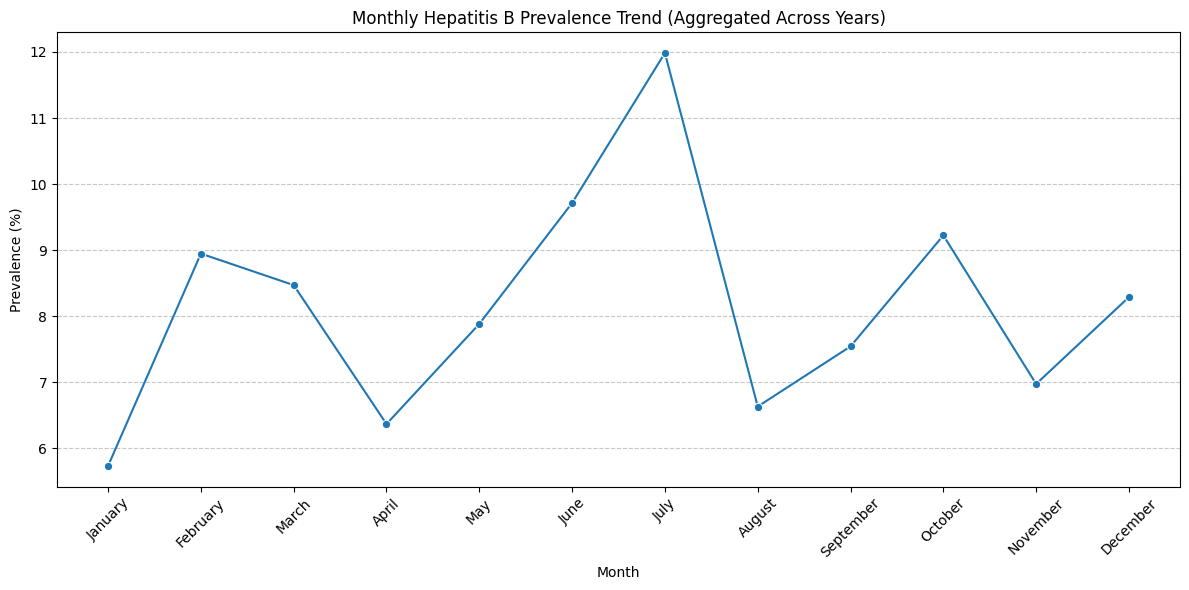

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out the 'Total' row for plotting
monthly_plot_df = monthly_display_df[monthly_display_df['Month'] != 'Total'].copy()

# Ensure months are in chronological order for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_plot_df['Month'] = pd.Categorical(monthly_plot_df['Month'], categories=month_order, ordered=True)
monthly_plot_df = monthly_plot_df.sort_values('Month')

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Prevalence (%)', data=monthly_plot_df, marker='o') # Changed to lineplot with markers
plt.title('Monthly Hepatitis B Prevalence Trend (Aggregated Across Years)')
plt.xlabel('Month')
plt.ylabel('Prevalence (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Time Series Forecasting: ARIMA and SARIMA



In [24]:
# Install pmdarima for auto-ARIMA/SARIMA parameter selection
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.2 MB/s eta 0:00:00


Initial NaN count: 0
First few values before anomaly handling:
Date
2020-07-01    115.620214
2020-08-01      7.011070
2020-09-01     11.853894
2020-10-01     13.241107
2020-11-01      6.149293
Name: Prevalence, dtype: float64
Anomaly detected at: [Timestamp('2020-07-01 00:00:00')] with original value 115.62021439509952.
Value at 2020-07-01 00:00:00 after setting to NaN: nan.
Value at 2020-07-01 00:00:00 after interpolation and fill: 7.011070110701106.
Final NaN count after handling: 0
First few values after anomaly handling:
Date
2020-07-01     7.011070
2020-08-01     7.011070
2020-09-01    11.853894
2020-10-01    13.241107
2020-11-01     6.149293
Name: Prevalence, dtype: float64

Prepared Time Series Head:


/tmp/ipykernel_484/1287875131.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_prevalence = temp_prevalence.fillna(method='bfill')
/tmp/ipykernel_484/1287875131.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_prevalence = temp_prevalence.fillna(method='ffill') # Should handle any remaining edge cases


,Prevalence
Date,
2020-07-01,7.011070
2020-08-01,7.011070
2020-09-01,11.853894
2020-10-01,13.241107
2020-11-01,6.149293


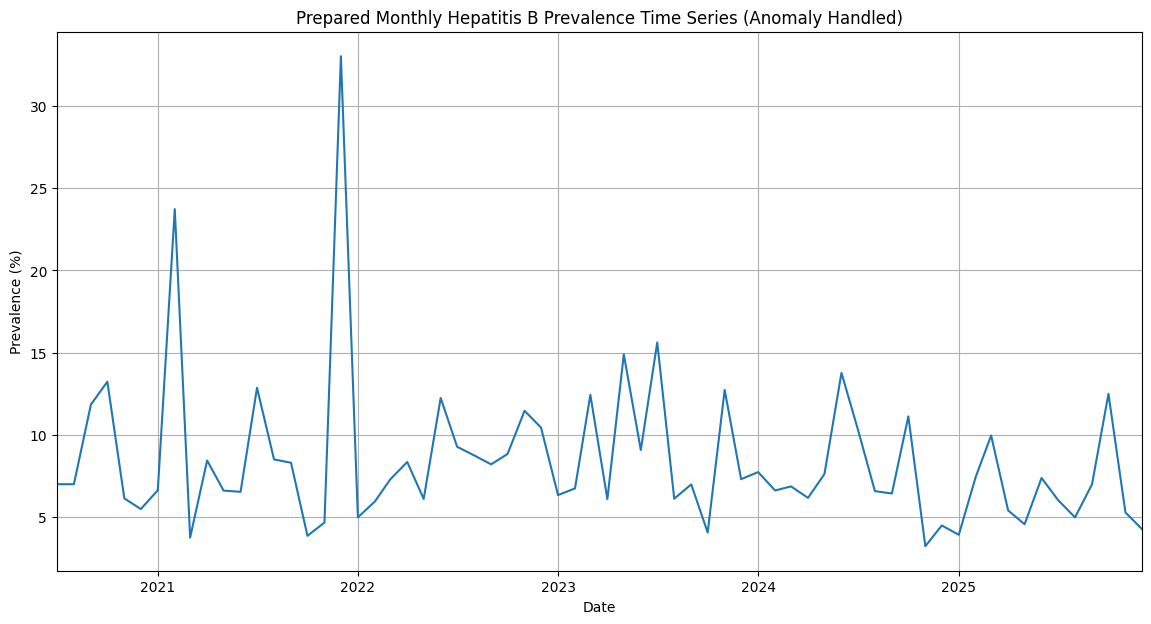

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a time series from df_year_month
ts_data = df_year_month[['Date', 'Prevalence']].set_index('Date').sort_index().copy() # Ensure ts_data is a true copy

# Ensure Prevalence column is numeric, coercing errors will turn non-numeric into NaN
ts_data['Prevalence'] = pd.to_numeric(ts_data['Prevalence'], errors='coerce')

print(f"Initial NaN count: {ts_data['Prevalence'].isnull().sum()}")
print(f"First few values before anomaly handling:\n{ts_data['Prevalence'].head()}")

# Handle the anomalous spike in July 2020 (115.620214)
# Make sure to work on the numeric column
anomaly_mask = ts_data['Prevalence'] > 100

if anomaly_mask.any():
    anomaly_index = ts_data[anomaly_mask].index.tolist()
    original_anomaly_value = ts_data.loc[anomaly_index[0], 'Prevalence'] # Store original value before setting to NaN
    print(f"Anomaly detected at: {anomaly_index} with original value {original_anomaly_value}.")

    # Replace anomaly with NaN
    ts_data.loc[anomaly_mask, 'Prevalence'] = np.nan
    print(f"Value at {anomaly_index[0]} after setting to NaN: {ts_data.loc[anomaly_index[0], 'Prevalence']}.")

    # Ensure all NaNs are handled: interpolate, then bfill, then ffill for robust filling
    temp_prevalence = ts_data['Prevalence'].interpolate(method='time')
    temp_prevalence = temp_prevalence.fillna(method='bfill')
    temp_prevalence = temp_prevalence.fillna(method='ffill') # Should handle any remaining edge cases

    ts_data['Prevalence'] = temp_prevalence

    print(f"Value at {anomaly_index[0]} after interpolation and fill: {ts_data.loc[anomaly_index[0], 'Prevalence']}.")
else:
    print("No anomaly greater than 100% found.")

print(f"Final NaN count after handling: {ts_data['Prevalence'].isnull().sum()}")
print(f"First few values after anomaly handling:\n{ts_data['Prevalence'].head()}")

# Display the prepared time series head
print("\nPrepared Time Series Head:")
display(ts_data.head())

# Plot the prepared time series
plt.figure(figsize=(14, 7))
plt.plot(ts_data.index, ts_data['Prevalence'])
plt.title('Prepared Monthly Hepatitis B Prevalence Time Series (Anomaly Handled)')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.grid(True)

# Set x-axis limits explicitly to the range of ts_data
plt.xlim(ts_data.index.min(), ts_data.index.max())

plt.show()

---

### ARIMA Model

Training data points: 52
Testing data points: 14
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=308.876, Time=0.73 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=316.389, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=315.319, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=310.474, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=392.117, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=310.371, Time=0.79 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=310.566, Time=0.85 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=308.763, Time=0.81 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=310.341, Time=1.22 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=312.134, Time=2.40 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=367.541, Time=0.67 sec

Best model:  ARIMA(0,0,2)(0,0,0)[0] intercept
Total fit time: 7.925 seconds
Optimal ARIMA parameters: (0, 0, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Prevalence   No. Observations:                   52
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -150.381
Date:                Sun, 02 Aug 2026   AIC                            308.763
Time:                        17:35:38   BIC                            316.568
Sample:                    07-01-2020   HQIC                           311.755
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1090      0.277     32.939      0.000       8.567       9.651
ma.L1         -0.4604      0.205     -2.242      0.025      -0.863      -0.058
ma.L2         -0.2516      0.245     -1.029      0.3

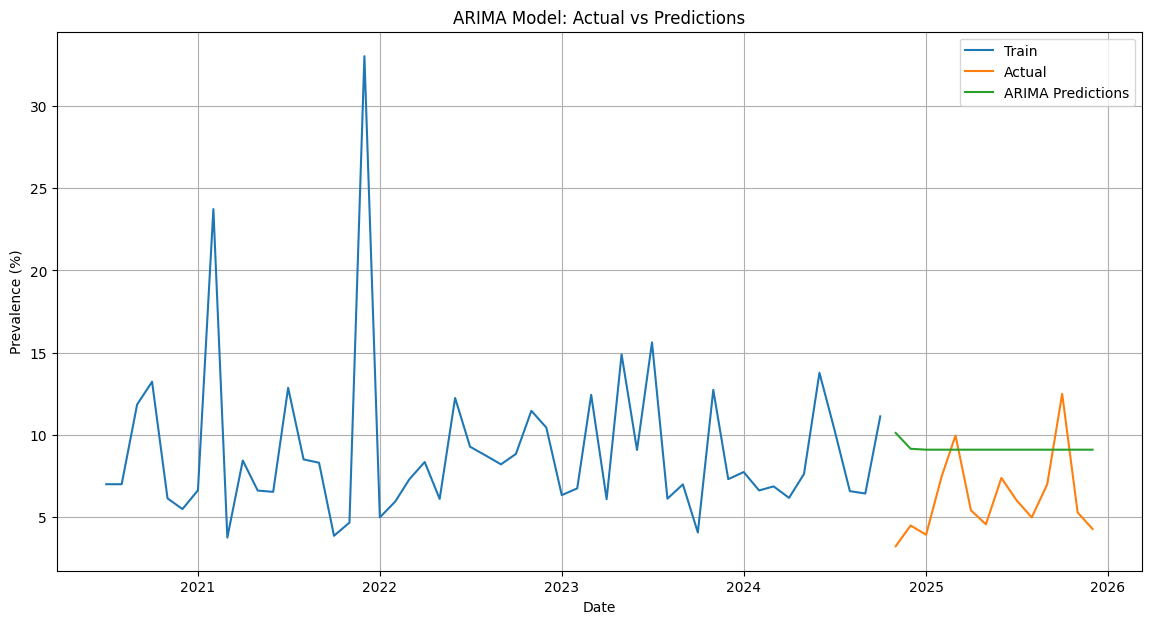

In [71]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

# Split data into training and testing sets
train_size = int(len(ts_data) * 0.8)
train_data, test_data = ts_data[0:train_size], ts_data[train_size:]

print(f"Training data points: {len(train_data)}")
print(f"Testing data points: {len(test_data)}")

# Find optimal ARIMA parameters using auto_arima
# (d=None will let auto_arima determine d, D=None for seasonal differencing)
# The seasonal=False argument explicitly requests a non-seasonal ARIMA model.

stepwise_fit = auto_arima(train_data['Prevalence'], start_p=1, start_q=1,
                           max_p=5, max_q=5, m=1,  # m=1 for non-seasonal data
                           d=None, trace=True,
                           error_action='ignore',  # don't want to stop on error
                           suppress_warnings=True,  # don't want convergence warnings
                           stepwise=True)

print("Optimal ARIMA parameters:", stepwise_fit.order)

# Fit ARIMA model with optimal parameters
arima_model = ARIMA(train_data['Prevalence'], order=stepwise_fit.order)
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary())

# Make predictions on the test set
arima_predictions = arima_model_fit.predict(start=len(train_data), end=len(ts_data)-1)

# Evaluate ARIMA model
rmse_arima = np.sqrt(mean_squared_error(test_data['Prevalence'], arima_predictions))
mae_arima = mean_absolute_error(test_data['Prevalence'], arima_predictions)

print(f"\nARIMA Model Evaluation:")
print(f"RMSE: {rmse_arima:.3f}")
print(f"MAE: {mae_arima:.3f}")

# Plot ARIMA predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Prevalence'], label='Train')
plt.plot(test_data.index, test_data['Prevalence'], label='Actual')
plt.plot(test_data.index, arima_predictions, label='ARIMA Predictions')
plt.title('ARIMA Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

---

### SARIMA Model

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=308.876, Time=0.35 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=316.389, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=316.823, Time=0.56 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=312.120, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=392.117, Time=0.02 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=310.592, Time=1.49 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=310.546, Time=1.46 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=2.15 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=310.474, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=315.319, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=310.371, Time=0.82 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=310.566, Time=1.80 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=308.763, Time=0.73 sec
 ARIMA(0,0,2)(1,0,0)[12] intercept   : AIC=310.603, Time=3.82 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


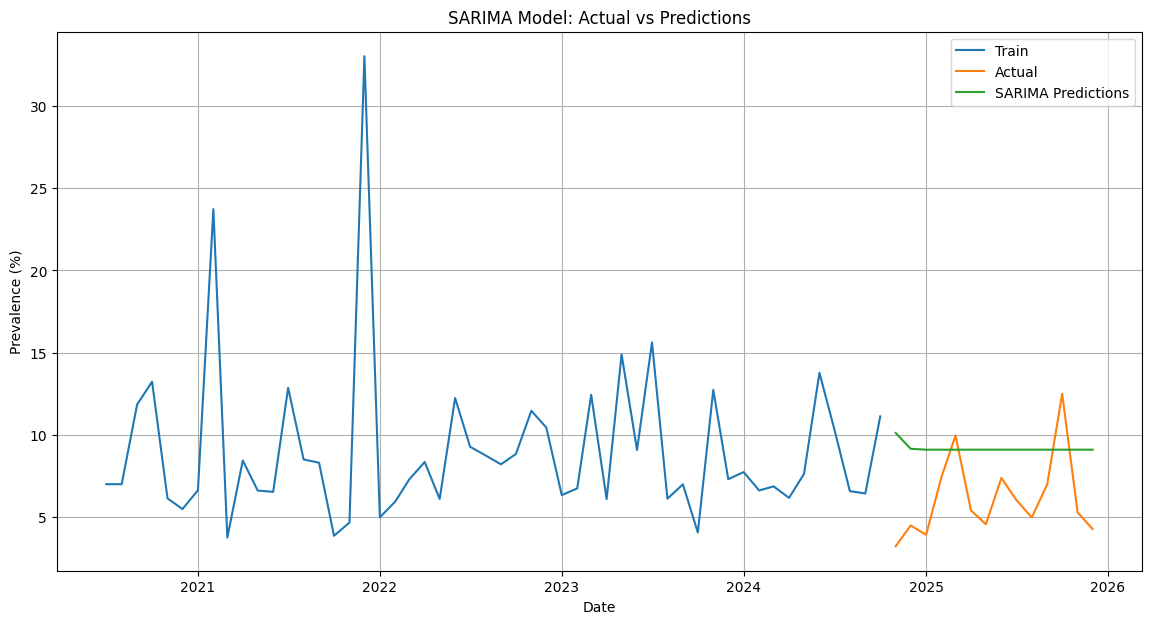

In [72]:
# Split data into training and testing sets (re-run to ensure clean data is used)
train_size = int(len(ts_data) * 0.8)
train_data, test_data = ts_data[0:train_size], ts_data[train_size:]

# Find optimal SARIMA parameters using auto_arima
# We'll assume a seasonal period (m) of 12 for monthly data.

stepwise_fit_sarima = auto_arima(train_data['Prevalence'], start_p=1, start_q=1,
                                 max_p=3, max_q=3, m=12,  # m=12 for monthly seasonality
                                 start_P=0, start_Q=0, max_P=2, max_Q=2,
                                 d=None, D=None, trace=True,
                                 error_action='ignore',  # don't want to stop on error
                                 suppress_warnings=True,  # don't want convergence warnings
                                 stepwise=True)

print("Optimal SARIMA parameters:", stepwise_fit_sarima.order, stepwise_fit_sarima.seasonal_order)

# Fit SARIMA model with optimal parameters
sarima_model = ARIMA(train_data['Prevalence'], order=stepwise_fit_sarima.order, seasonal_order=stepwise_fit_sarima.seasonal_order)
sarima_model_fit = sarima_model.fit()
print(sarima_model_fit.summary())

# Make predictions on the test set
sarima_predictions = sarima_model_fit.predict(start=len(train_data), end=len(ts_data)-1)

# Evaluate SARIMA model
rmse_sarima = np.sqrt(mean_squared_error(test_data['Prevalence'], sarima_predictions))
mae_sarima = mean_absolute_error(test_data['Prevalence'], sarima_predictions)

print(f"\nSARIMA Model Evaluation:")
print(f"RMSE: {rmse_sarima:.3f}")
print(f"MAE: {mae_sarima:.3f}")

# Plot SARIMA predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Prevalence'], label='Train')
plt.plot(test_data.index, test_data['Prevalence'], label='Actual')
plt.plot(test_data.index, sarima_predictions, label='SARIMA Predictions')
plt.title('SARIMA Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

---

### Model Comparison

,RMSE,MAE
Model,,
ARIMA,3.932088,3.605245
SARIMA,3.932088,3.605245


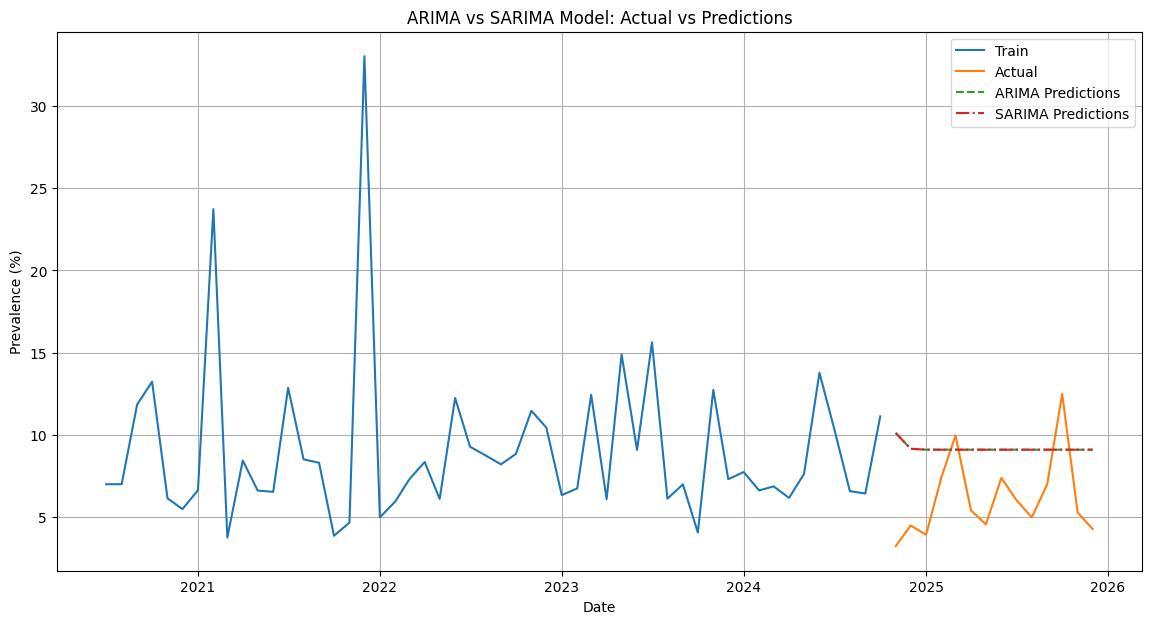

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'RMSE': [rmse_arima, rmse_sarima],
    'MAE': [mae_arima, mae_sarima]
})

display(comparison_df.set_index('Model'))

# Plot both predictions together for comparison
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Prevalence'], label='Train')
plt.plot(test_data.index, test_data['Prevalence'], label='Actual')
plt.plot(test_data.index, arima_predictions, label='ARIMA Predictions', linestyle='--')
plt.plot(test_data.index, sarima_predictions, label='SARIMA Predictions', linestyle='-.')
plt.title('ARIMA vs SARIMA Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

##  Machine Learning Models for Time Series Forecasting





### Prophet Model

In [36]:
# Install Prophet library
!pip install prophet


Prophet Model Evaluation:
RMSE: 5.208
MAE: 3.990


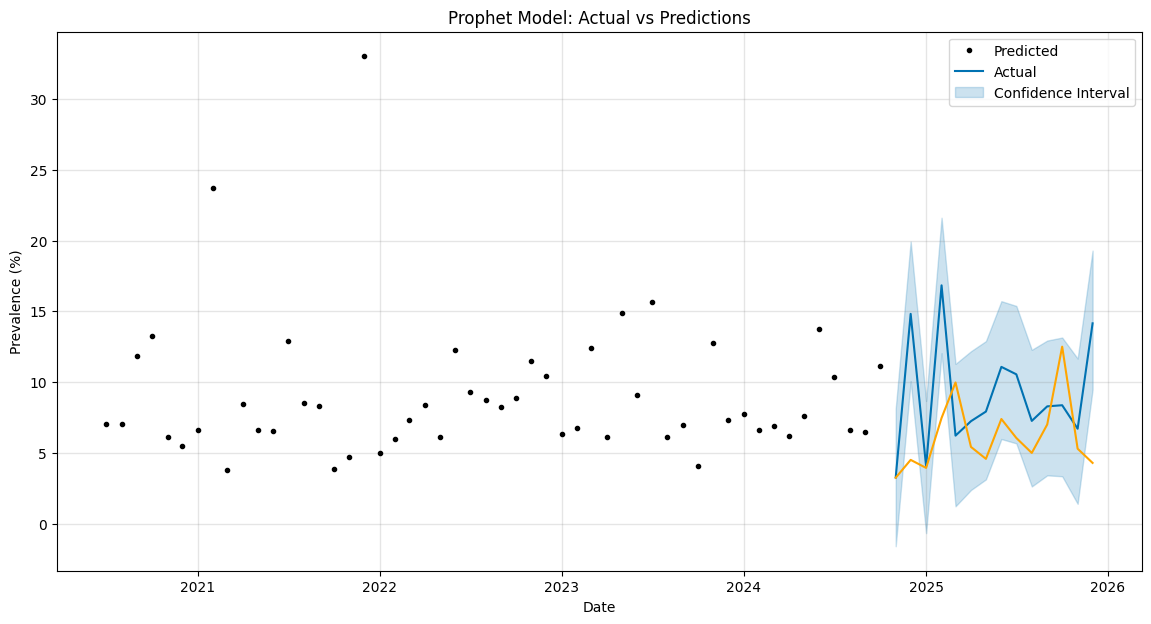

In [73]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prophet requires the dataframe to have columns named 'ds' (datestamp) and 'y' (value)
prophet_df = ts_data.reset_index().rename(columns={'Date': 'ds', 'Prevalence': 'y'})

# Split data into training and testing sets (using the same split points as before)
train_size_prophet = int(len(prophet_df) * 0.8)
train_prophet, test_prophet = prophet_df[0:train_size_prophet], prophet_df[train_size_prophet:]

# Initialize and train the Prophet model
# Set daily_seasonality=False if not applicable or too fine-grained for monthly data
prophet_model = Prophet(weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(train_prophet)

# Create a dataframe for future predictions (test set dates)
future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='MS')
future = future[future['ds'].isin(test_prophet['ds'])] # Filter to only test set dates

# Make predictions
forecast = prophet_model.predict(future)
prophet_predictions = forecast['yhat'].values

# Ensure predictions are non-negative
prophet_predictions[prophet_predictions < 0] = 0

# Evaluate Prophet model
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], prophet_predictions))
mae_prophet = mean_absolute_error(test_prophet['y'], prophet_predictions)

print(f"\nProphet Model Evaluation:")
print(f"RMSE: {rmse_prophet:.3f}")
print(f"MAE: {mae_prophet:.3f}")

# Plot Prophet predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 7))
prophet_model.plot(forecast, ax=ax)
ax.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='orange') # Plot actual test data
ax.set_title('Prophet Model: Actual vs Predictions')
ax.set_xlabel('Date')
ax.set_ylabel('Prevalence (%)')
plt.legend(['Predicted', 'Actual', 'Confidence Interval'])
plt.grid(True)
plt.show()

### Exponential Smoothing (ETS) Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



ETS Model Evaluation:
RMSE: 4.649
MAE: 3.933


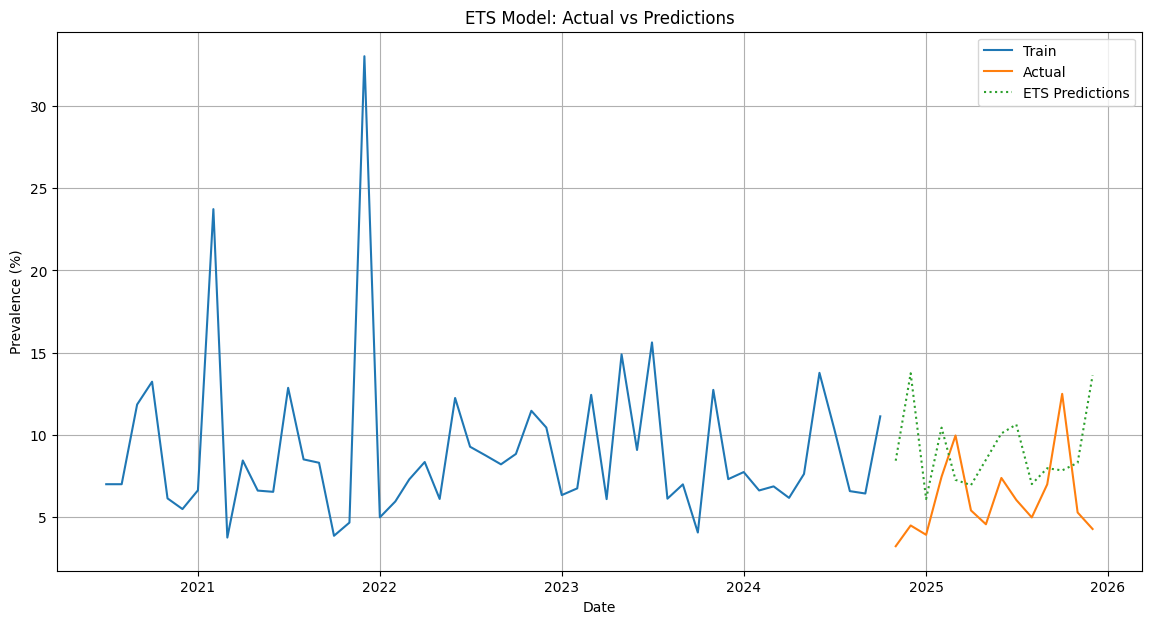

In [74]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train the ETS model on the training data
# We'll use additive trend and seasonal components, as prevalence is likely to have these characteristics.
# Seasonal period (m) is 12 for monthly data.
# 'add' for additive trend, 'add' for additive seasonality, if 'mul' is not appropriate.
# adjust_start_dates=True ensures that the forecast starts from the test data start index
ets_model = ExponentialSmoothing(
    train_data['Prevalence'],
    seasonal='add', # additive seasonality
    seasonal_periods=12, # 12 months for seasonality
    trend='add' # additive trend
).fit()

# Make predictions on the test set
ets_predictions = ets_model.predict(start=test_data.index[0], end=test_data.index[-1])

# Ensure predictions are non-negative
ets_predictions[ets_predictions < 0] = 0

# Evaluate ETS model
rmse_ets = np.sqrt(mean_squared_error(test_data['Prevalence'], ets_predictions))
mae_ets = mean_absolute_error(test_data['Prevalence'], ets_predictions)

print(f"\nETS Model Evaluation:")
print(f"RMSE: {rmse_ets:.3f}")
print(f"MAE: {mae_ets:.3f}")

# Plot ETS predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Prevalence'], label='Train')
plt.plot(test_data.index, test_data['Prevalence'], label='Actual')
plt.plot(test_data.index, ets_predictions, label='ETS Predictions', linestyle=':')
plt.title('ETS Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

### Feature Engineering for Supervised Learning Models

In [39]:
def create_features(data):
    df = data.copy()
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    df['quarter'] = df.index.quarter

    # Lag features
    df['lag_1'] = df['Prevalence'].shift(1)
    df['lag_2'] = df['Prevalence'].shift(2)
    df['lag_3'] = df['Prevalence'].shift(3)

    # Rolling window features
    df['rolling_mean_3'] = df['Prevalence'].rolling(window=3).mean()
    df['rolling_std_3'] = df['Prevalence'].rolling(window=3).std()

    return df.dropna()

# Apply feature engineering to the full ts_data
ts_data_fe = create_features(ts_data)

# Split the feature-engineered data into training and testing sets
# Ensure the split maintains the temporal order
train_size_fe = int(len(ts_data_fe) * 0.8)
train_fe, test_fe = ts_data_fe[0:train_size_fe], ts_data_fe[train_size_fe:]

X_train, y_train = train_fe.drop('Prevalence', axis=1), train_fe['Prevalence']
X_test, y_test = test_fe.drop('Prevalence', axis=1), test_fe['Prevalence']

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
display(X_train.head())


Shape of X_train: (50, 11)
Shape of y_train: (50,)
Shape of X_test: (13, 11)
Shape of y_test: (13,)


,year,month,dayofweek,dayofyear,weekofyear,quarter,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
Date,,,,,,,,,,,
2020-10-01,2020,10,3,275,40,4,11.853894,7.011070,7.011070,10.702024,3.270847
2020-11-01,2020,11,6,306,44,4,13.241107,11.853894,7.011070,10.414765,3.758560
2020-12-01,2020,12,1,336,49,4,6.149293,13.241107,11.853894,8.296983,4.294006
2021-01-01,2021,1,4,1,53,1,5.500550,6.149293,13.241107,6.096823,0.571846
2021-02-01,2021,2,0,32,5,1,6.640625,5.500550,6.149293,11.957007,10.211500


### LightGBM Model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 149
[LightGBM] [Info] Number of data points in the train set: 50, number of used features: 11
[LightGBM] [Info] Start training from score 8.982242
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

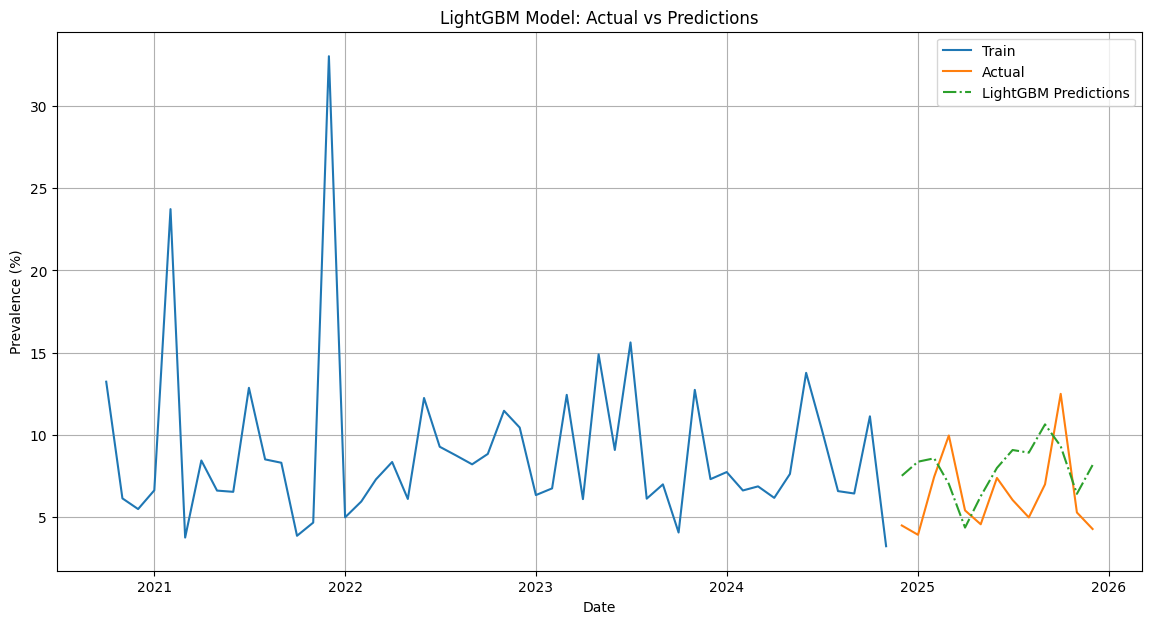

In [75]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize and train the LightGBM Regressor model
lgbm_model = lgb.LGBMRegressor(random_state=42)
lgbm_model.fit(X_train, y_train)

# Make predictions
lgbm_predictions = lgbm_model.predict(X_test)

# Ensure predictions are non-negative
lgbm_predictions[lgbm_predictions < 0] = 0

# Evaluate LightGBM model
rmse_lgbm = np.sqrt(mean_squared_error(y_test, lgbm_predictions))
mae_lgbm = mean_absolute_error(y_test, lgbm_predictions)

print(f"\nLightGBM Model Evaluation:")
print(f"RMSE: {rmse_lgbm:.3f}")
print(f"MAE: {mae_lgbm:.3f}")

# Plot LightGBM predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(X_train.index, y_train, label='Train')
plt.plot(X_test.index, y_test, label='Actual')
plt.plot(X_test.index, lgbm_predictions, label='LightGBM Predictions', linestyle='-.')
plt.title('LightGBM Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest Regressor Model


Random Forest Model Evaluation:
RMSE: 1.966
MAE: 1.611


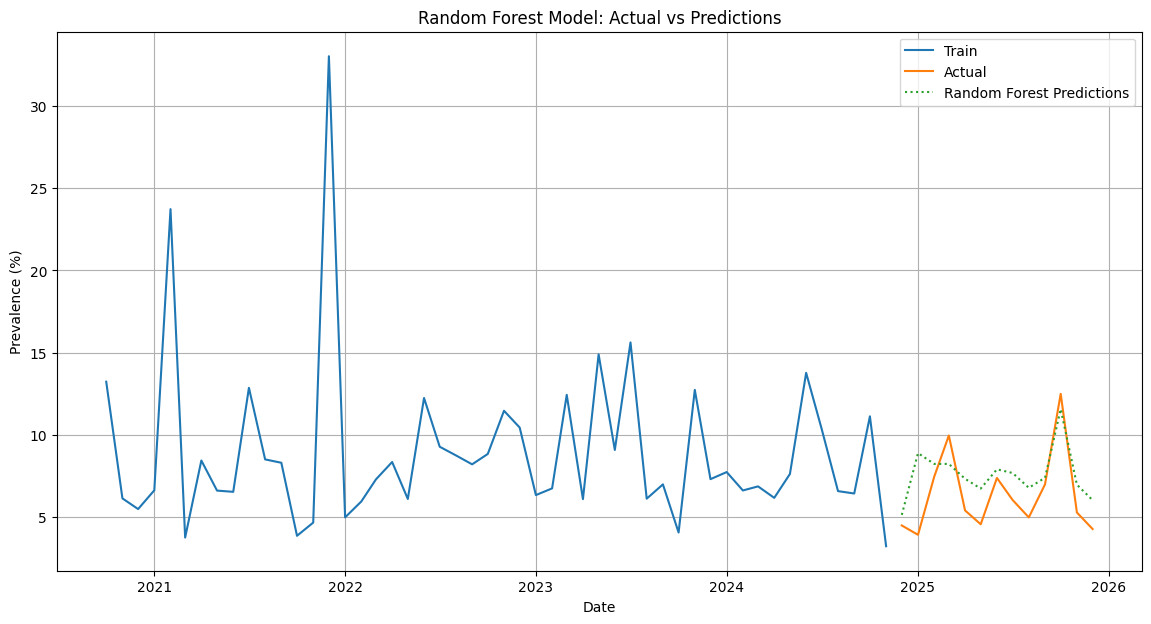

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Ensure predictions are non-negative
rf_predictions[rf_predictions < 0] = 0

# Evaluate Random Forest model
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
mae_rf = mean_absolute_error(y_test, rf_predictions)

print(f"\nRandom Forest Model Evaluation:")
print(f"RMSE: {rmse_rf:.3f}")
print(f"MAE: {mae_rf:.3f}")

# Plot Random Forest predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(X_train.index, y_train, label='Train')
plt.plot(X_test.index, y_test, label='Actual')
plt.plot(X_test.index, rf_predictions, label='Random Forest Predictions', linestyle=':')
plt.title('Random Forest Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

### Support Vector Regressor (SVR) Model


SVR Model Evaluation:
RMSE: 2.293
MAE: 2.058


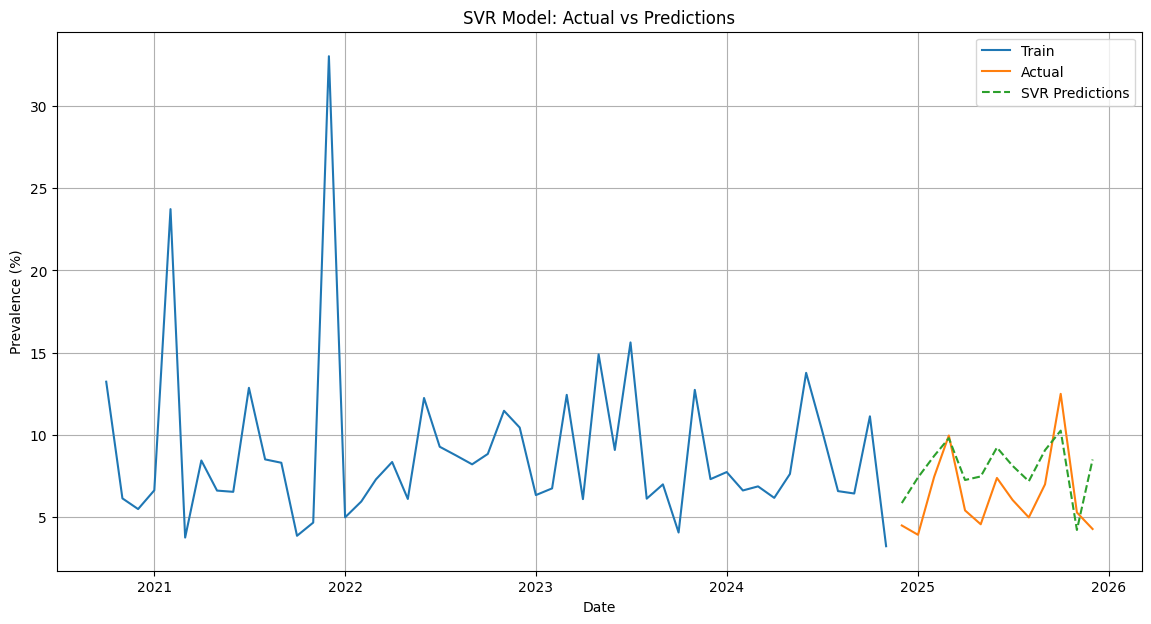

In [77]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# SVR is sensitive to feature scaling, so scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test_scaled = scaler_X.transform(X_test)

# Initialize and train the SVR model
# Using a radial basis function (rbf) kernel
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# Make predictions on scaled test data and then inverse transform
svr_predictions_scaled = svr_model.predict(X_test_scaled)
svr_predictions = scaler_y.inverse_transform(svr_predictions_scaled.reshape(-1, 1)).flatten()

# Ensure predictions are non-negative
svr_predictions[svr_predictions < 0] = 0

# Evaluate SVR model
rmse_svr = np.sqrt(mean_squared_error(y_test, svr_predictions))
mae_svr = mean_absolute_error(y_test, svr_predictions)

print(f"\nSVR Model Evaluation:")
print(f"RMSE: {rmse_svr:.3f}")
print(f"MAE: {mae_svr:.3f}")

# Plot SVR predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(X_train.index, y_train, label='Train')
plt.plot(X_test.index, y_test, label='Actual')
plt.plot(X_test.index, svr_predictions, label='SVR Predictions', linestyle='--')
plt.title('SVR Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

### Comprehensive Model Comparison

In [79]:
import pandas as pd

final_comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Prophet', 'ETS', 'LightGBM', 'Random Forest', 'SVR', 'Hybrid'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_prophet, rmse_ets, rmse_lgbm, rmse_rf, rmse_svr, rmse_hybrid],
    'MAE': [mae_arima, mae_sarima, mae_prophet, mae_ets, mae_lgbm, mae_rf, mae_svr, mae_hybrid]
})

final_comparison_df = final_comparison_df.set_index('Model').sort_values(by='RMSE')

print("\n--- Overall Model Performance Comparison (Sorted by RMSE) ---")
display(final_comparison_df[['RMSE', 'MAE']])


--- Overall Model Performance Comparison (Sorted by RMSE) ---


,RMSE,MAE
Model,,
Random Forest,1.965803,1.611015
SVR,2.292543,2.058171
Hybrid,2.705144,2.482048
LightGBM,2.878170,2.592830
SARIMA,3.932088,3.605245
ARIMA,3.932088,3.605245
ETS,4.648855,3.933224
Prophet,5.207719,3.990371


In [ ]:
def create_features(data):
    df = data.copy()
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    df['quarter'] = df.index.quarter

    # Lag features
    df['lag_1'] = df['Prevalence'].shift(1)
    df['lag_2'] = df['Prevalence'].shift(2)
    df['lag_3'] = df['Prevalence'].shift(3)

    # Rolling window features
    df['rolling_mean_3'] = df['Prevalence'].rolling(window=3).mean()
    df['rolling_std_3'] = df['Prevalence'].rolling(window=3).std()

    return df.dropna()

# Apply feature engineering to the full ts_data
ts_data_fe = create_features(ts_data)

# Split the feature-engineered data into training and testing sets
# Ensure the split maintains the temporal order
train_size_fe = int(len(ts_data_fe) * 0.8)
train_fe, test_fe = ts_data_fe[0:train_size_fe], ts_data_fe[train_size_fe:]

X_train, y_train = train_fe.drop('Prevalence', axis=1), train_fe['Prevalence']
X_test, y_test = test_fe.drop('Prevalence', axis=1), test_fe['Prevalence']

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
display(X_train.head())

Shape of X_train: (50, 11)
Shape of y_train: (50,)
Shape of X_test: (13, 11)
Shape of y_test: (13,)


,year,month,dayofweek,dayofyear,weekofyear,quarter,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
Date,,,,,,,,,,,
2020-10-01,2020,10,3,275,40,4,11.853894,7.011070,7.011070,10.702024,3.270847
2020-11-01,2020,11,6,306,44,4,13.241107,11.853894,7.011070,10.414765,3.758560
2020-12-01,2020,12,1,336,49,4,6.149293,13.241107,11.853894,8.296983,4.294006
2021-01-01,2021,1,4,1,53,1,5.500550,6.149293,13.241107,6.096823,0.571846
2021-02-01,2021,2,0,32,5,1,6.640625,5.500550,6.149293,11.957007,10.211500


### Hybrid Model (ARIMA + Random Forest)


Hybrid Model Evaluation:
RMSE: 2.705
MAE: 2.482


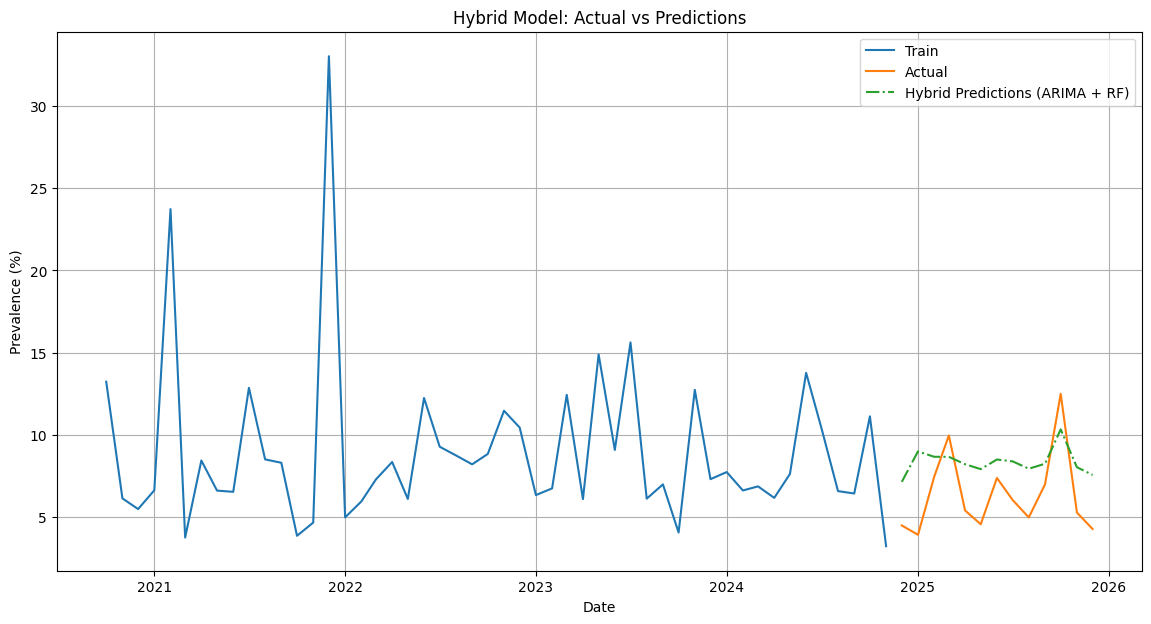

In [78]:
# Align ARIMA predictions to the dates covered by y_test (from the feature-engineered data)
# y_test's index starts from 2024-12-01, while arima_predictions starts from 2024-11-01.
arima_predictions_aligned = arima_predictions.loc[y_test.index]

# Create hybrid predictions by taking a simple average of aligned ARIMA and Random Forest predictions
hybrid_predictions = (arima_predictions_aligned.values + rf_predictions) / 2

# Ensure predictions are non-negative
hybrid_predictions[hybrid_predictions < 0] = 0

# Evaluate Hybrid model
rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_predictions))
mae_hybrid = mean_absolute_error(y_test, hybrid_predictions)

print(f"\nHybrid Model Evaluation:")
print(f"RMSE: {rmse_hybrid:.3f}")
print(f"MAE: {mae_hybrid:.3f}")

# Plot Hybrid predictions vs actuals
plt.figure(figsize=(14, 7))
plt.plot(X_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, hybrid_predictions, label='Hybrid Predictions (ARIMA + RF)', linestyle='-.')
plt.title('Hybrid Model: Actual vs Predictions')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
def upload_plt_to_gcs(num_fig, step, plt_obj):
    """Placeholder function to simulate uploading plot artifacts to GCS."""
    print(f"[INFO] Simulating upload of plot {num_fig} for step '{step}' to GCS.")
    print(" (In a real scenario, this would involve GCS client library calls to upload the plot data.)")

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'HybridModel'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
upload_plt_to_gcs(num_fig, step, plt)

[INFO] Simulating upload of plot 1 for step 'HybridModel' to GCS.
 (In a real scenario, this would involve GCS client library calls to upload the plot data.)
